<a href="https://colab.research.google.com/github/DaviTeobaldo/House-Prices-MachineLearning/blob/main/House_Prices_Prediction_with_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Contextualização do problema


# House Prices - Advanced Regression Techniques

### Projeto de Machine Learning — Predição de Preços de Imóveis

## 1. Contextualização do problema

Este notebook resolve a competição do Kaggle **[House Prices - Advanced Regression
Techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques)**,
uma competição "Getting Started" voltada à prática de **feature engineering**,
regressão e modelos de ensemble (Random Forests, Gradient Boosting).

**Descrição da competição (Kaggle):**
> *"Ask a home buyer to describe their dream house, and they probably won't begin
> with the height of the basement ceiling or the proximity to an east-west railroad.
> But this playground competition's dataset proves that much more influences price
> negotiations than the number of bedrooms or a white-picket fence."*

O conjunto de dados (Ames Housing Dataset, compilado por Dean De Cock) contém
**79 variáveis explicativas** que descrevem quase todos os aspectos de casas
residenciais na cidade de Ames, Iowa (EUA), e o objetivo é prever a variável
`SalePrice` (preço de venda) para o conjunto de teste.

### 1.1 Objetivo

Construir um pipeline de Machine Learning que:

1. Realize uma **Análise Exploratória de Dados (EDA)** para entender a distribuição
   das variáveis e sua relação com o preço de venda;
2. Faça o **pré-processamento** dos dados (tratamento de valores ausentes,
   codificação de variáveis categóricas, tratamento de assimetria);
3. Realize **engenharia de atributos (feature engineering)**;
4. Treine e compare **diversos modelos de regressão** vistos em disciplinas de
   Aprendizado de Máquina de graduação (Regressão Linear, Ridge, Lasso,
   Random Forest, Gradient Boosting), usando **validação cruzada**;
5. Faça **ajuste de hiperparâmetros (hyperparameter tuning)** do(s) melhor(es)
   modelo(s);
6. Gere o arquivo de submissão (`submission.csv`) para o Kaggle.

### 1.2 Métrica de avaliação

A competição avalia as submissões pelo **RMSLE — Root Mean Squared Logarithmic
Error** entre o logaritmo do valor previsto e o logaritmo do valor observado:

$$
\text{RMSLE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}\left(\log(\hat{y}_i + 1) - \log(y_i + 1)\right)^2}
$$

Usar o log do preço tem duas vantagens práticas importantes que exploraremos
neste notebook:

- Penaliza proporcionalmente erros em casas baratas e caras (erro relativo, não
  absoluto);
- A distribuição de `SalePrice` é assimétrica à direita (right-skewed); aplicar
  `log1p` a aproxima de uma distribuição normal, o que favorece modelos lineares.

Por isso, ao longo do notebook trabalharemos diretamente com `log(SalePrice)`
como alvo, de forma que o **RMSE calculado sobre o alvo em log já corresponde ao
RMSLE** pedido pela competição.

### 1.3 Estrutura do notebook

| Seção | Conteúdo |
|---|---|
| 2 | Análise Exploratória de Dados (EDA) |
| 3 | Pré-processamento e Engenharia de Atributos |
| 4 | Preparação para modelagem (validação cruzada, métricas) |
| 5 | Modelos lineares (Regressão Linear, Ridge, Lasso, ElasticNet) |
| 6 | Modelos baseados em árvores (Random Forest, Gradient Boosting) |
| 7 | Comparação dos modelos |
| 8 | Otimização de hiperparâmetros |
| 9 | Ensemble dos melhores modelos |
| 10 | Treinamento final e geração da submissão |
| 11 | Conclusão |


# 2. Configurando o ambiente e importando os dados

In [7]:
# Manipulação de dados
import numpy as np
import pandas as pd

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Estatística
from scipy import stats
from scipy.stats import skew

# Pré-processamento e modelagem (scikit-learn)
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV, train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore")

# Configurações de visualização
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)

print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [8]:
TRAIN_PATH = "train.csv"
TEST_PATH = "test.csv"

# Faz upload interativo apenas se estivermos rodando no Google Colab
# e os arquivos ainda não existirem no ambiente.
import os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB and not (os.path.exists(TRAIN_PATH) and os.path.exists(TEST_PATH)):
    from google.colab import files
    print("Faça o upload de train.csv e test.csv:")
    uploaded = files.upload()

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

print(f"train: {train.shape[0]} linhas x {train.shape[1]} colunas")
print(f"test : {test.shape[0]} linhas x {test.shape[1]} colunas")

train: 1460 linhas x 81 colunas
test : 1459 linhas x 80 colunas


# 3. Análise Exploratória de Dados

Antes de qualquer modelagem, é fundamental entender o comportamento dos dados:
tipos de variáveis, valores ausentes, distribuição do alvo e relações entre as
principais features e `SalePrice`.

In [9]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [10]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## 3.1 Distribuição da variável alvo (SalePrice)

Como discutido na contextualização, esperamos uma distribuição assimétrica à
direita. Comparamos a distribuição original com a distribuição após a
transformação `log1p` (usada como alvo real de treinamento).

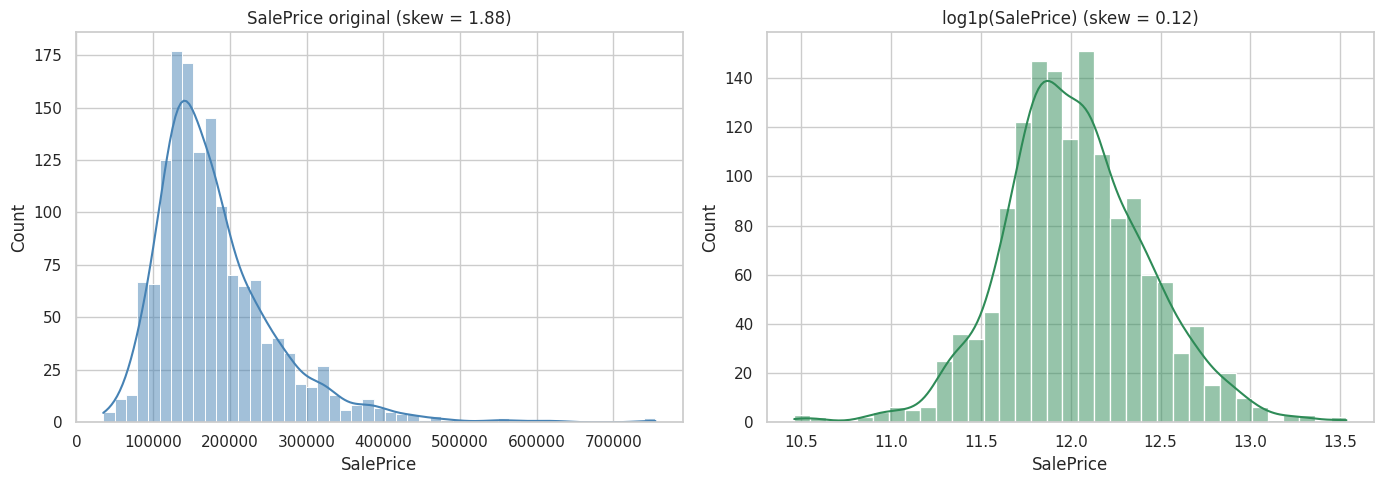

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train["SalePrice"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title(f"SalePrice original (skew = {skew(train['SalePrice']):.2f})")

log_price = np.log1p(train["SalePrice"])
sns.histplot(log_price, kde=True, ax=axes[1], color="seagreen")
axes[1].set_title(f"log1p(SalePrice) (skew = {skew(log_price):.2f})")

plt.tight_layout()
plt.show()

## 3.2 Trabalhar com valores ausentes

In [14]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(2)

missing_df = pd.DataFrame({"n_ausentes": missing, "pct_ausentes": missing_pct})
print(f"Número de colunas com valores ausentes: {len(missing_df)}")
missing_df

Número de colunas com valores ausentes: 19


,n_ausentes,pct_ausentes
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


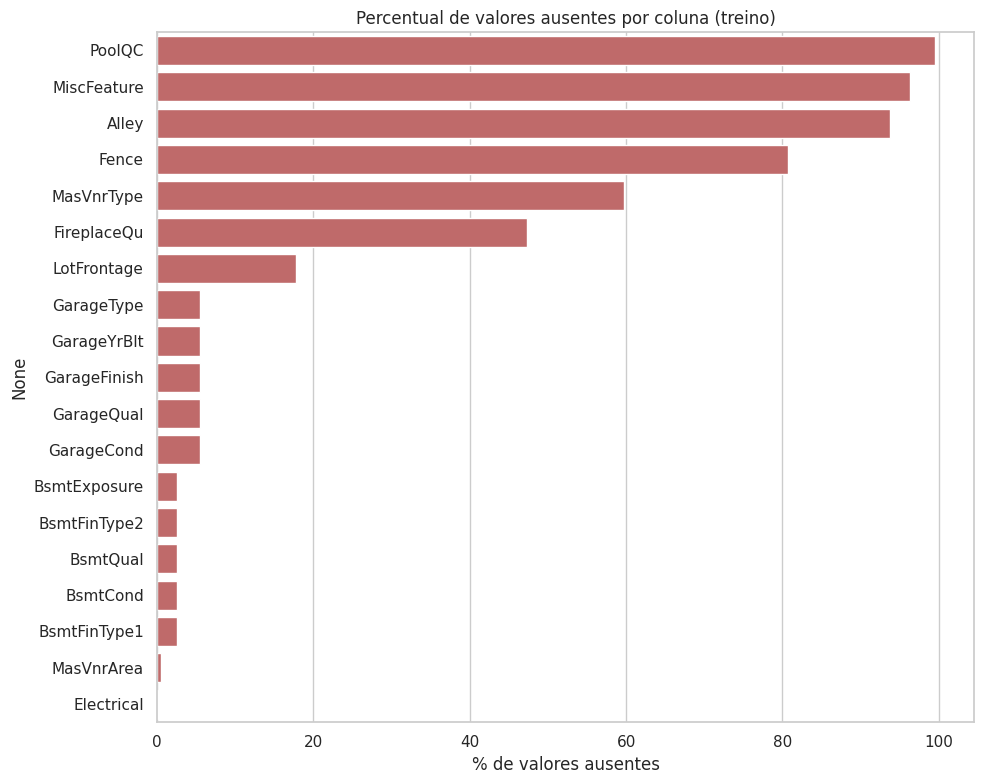

In [15]:
plt.figure(figsize=(10, 8))
sns.barplot(x=missing_pct.values, y=missing_pct.index, color="indianred")
plt.xlabel("% de valores ausentes")
plt.title("Percentual de valores ausentes por coluna (treino)")
plt.tight_layout()
plt.show()

## 3.3 Correlação com o SalePrice

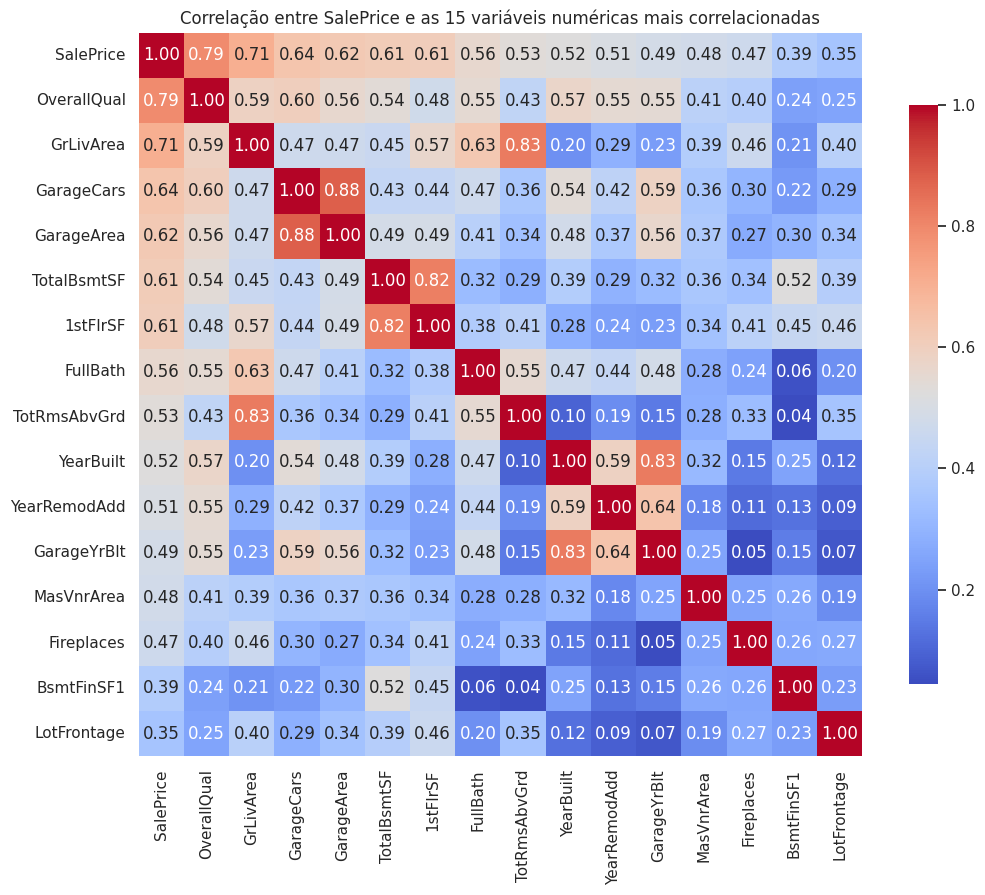

In [16]:
corr = train.corr(numeric_only=True)
top_corr = corr["SalePrice"].abs().sort_values(ascending=False).head(16).index

plt.figure(figsize=(11, 9))
sns.heatmap(train[top_corr].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlação entre SalePrice e as 15 variáveis numéricas mais correlacionadas")
plt.tight_layout()
plt.show()

## 3.4 Relação intrínseca entre as principais variáveis e SalePrice

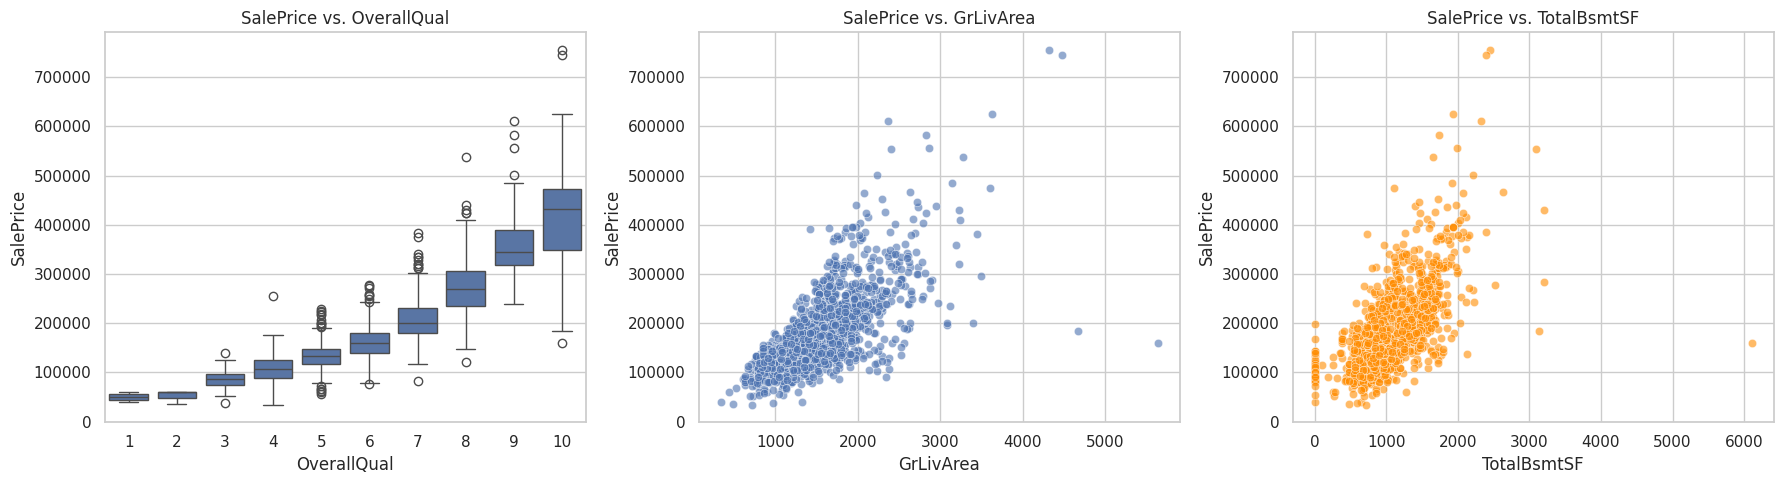

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x="OverallQual", y="SalePrice", data=train, ax=axes[0])
axes[0].set_title("SalePrice vs. OverallQual")

sns.scatterplot(x="GrLivArea", y="SalePrice", data=train, ax=axes[1], alpha=0.6)
axes[1].set_title("SalePrice vs. GrLivArea")

sns.scatterplot(x="TotalBsmtSF", y="SalePrice", data=train, ax=axes[2], alpha=0.6, color="darkorange")
axes[2].set_title("SalePrice vs. TotalBsmtSF")

plt.tight_layout()
plt.show()

## 3.5 Remoção de outliers

In [18]:
outliers_idx = train[(train["GrLivArea"] > 4000) & (train["SalePrice"] < 300000)].index
print(f"Removendo {len(outliers_idx)} outlier(s) de treino.")

train = train.drop(outliers_idx).reset_index(drop=True)
print(f"Novo shape de treino: {train.shape}")

Removendo 2 outlier(s) de treino.
Novo shape de treino: (1458, 81)


# 3. Pré-processamento e Engenharia de Atributos

# 3.1 Aglutinação de treino e teste
Para garantir que o tratamento de valores ausentes, a codificação categórica e
a engenharia de atributos sejam **exatamente consistentes** entre treino e
teste (mesmas colunas, mesmas categorias), concatenamos os dois conjuntos
antes do pré-processamento e os separamos novamente ao final (Seção 3.7).

In [19]:
ntrain = train.shape[0]
ntest = test.shape[0]

y_train = np.log1p(train["SalePrice"]).values # alvo em log1p

test_ids = test["Id"]

all_data = pd.concat([train.drop(columns=["SalePrice"]), test], axis=0, sort=False)
all_data = all_data.drop(columns=["Id"]).reset_index(drop=True)

print(f"all_data: {all_data.shape}")

all_data: (2917, 79)


## 3.2 Tratamento de valores ausentes
Seguimos a documentação oficial do dataset (`data_description.txt` da
competição) para tratar cada grupo de colunas de forma coerente com o seu
significado:

- **Variáveis categóricas em que `NaN` = "ausência da característica"**
  (ex.: `PoolQC`, `Alley`, `Fence`, `FireplaceQu`, variáveis de garagem e de
  porão) → preenchidas com `"None"`;
- **Variáveis numéricas associadas às mesmas características** (ex.: área de
  garagem quando não há garagem) → preenchidas com `0`;
- **`LotFrontage`** (testada do lote) → preenchida com a **mediana por
  bairro** (`Neighborhood`), pois lotes do mesmo bairro tendem a ter
  dimensões parecidas;
- **Demais colunas categóricas com poucos ausentes** → preenchidas com a
  **moda**;
- **`Utilities`** → possui variância quase nula (quase todos os valores são
  iguais) e é descartada, pois não agrega poder preditivo.

In [20]:
cols_none = [
    "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "MasVnrType",
]
for col in cols_none:
    all_data[col] = all_data[col].fillna("None")

# --- Numéricas onde NaN significa "0" (ausência da característica) ---
cols_zero = [
    "GarageYrBlt", "GarageArea", "GarageCars",
    "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
    "BsmtFullBath", "BsmtHalfBath", "MasVnrArea",
]
for col in cols_zero:
    all_data[col] = all_data[col].fillna(0)

# --- LotFrontage: mediana por bairro ---
all_data["LotFrontage"] = all_data.groupby("Neighborhood")["LotFrontage"] \
    .transform(lambda s: s.fillna(s.median()))
all_data["LotFrontage"] = all_data["LotFrontage"].fillna(all_data["LotFrontage"].median())

# --- Coluna quase constante: descartar ---
all_data = all_data.drop(columns=["Utilities"])

# --- Demais colunas categóricas: preencher com a moda ---
cols_mode = [
    "MSZoning", "Electrical", "KitchenQual", "Exterior1st", "Exterior2nd",
    "SaleType", "Functional",
]
for col in cols_mode:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

remaining_na = all_data.isnull().sum()
remaining_na = remaining_na[remaining_na > 0]
print("Colunas com valores ausentes remanescentes:")
print(remaining_na if len(remaining_na) else "Nenhuma")


Colunas com valores ausentes remanescentes:
Nenhuma


## 3.3 Engenharia de atributos
Criamos atributos derivados que costumam ter forte poder preditivo neste
problema, combinando informações que já existem no dataset:

- `TotalSF`: área total do imóvel (porão + 1º andar + 2º andar);
- `HouseAge`: idade da casa no momento da venda;
- `RemodAge`: anos desde a última reforma;
- `GarageAge`: idade da garagem no momento da venda;
- `TotalBath`: número total de banheiros (equivalente, contando lavabos como
  meio banheiro);
- `TotalPorchSF`: soma de todas as áreas de varanda/deck;
- `HasPool`, `Has2ndFloor`, `HasGarage`, `HasBsmt`, `HasFireplace`:
  indicadores binários de presença da característica;
- `IsRemodeled`: indicador se a casa foi reformada (`YearRemodAdd != YearBuilt`).

In [21]:
all_data["TotalSF"] = all_data["TotalBsmtSF"] + all_data["1stFlrSF"] + all_data["2ndFlrSF"]

all_data["HouseAge"] = all_data["YrSold"] - all_data["YearBuilt"]
all_data["RemodAge"] = all_data["YrSold"] - all_data["YearRemodAdd"]
all_data["GarageAge"] = (all_data["YrSold"] - all_data["GarageYrBlt"]).clip(lower=0)
all_data.loc[all_data["GarageYrBlt"] == 0, "GarageAge"] = 0

all_data["TotalBath"] = (
    all_data["FullBath"] + 0.5 * all_data["HalfBath"]
    + all_data["BsmtFullBath"] + 0.5 * all_data["BsmtHalfBath"]
)

all_data["TotalPorchSF"] = (
    all_data["OpenPorchSF"] + all_data["EnclosedPorch"]
    + all_data["3SsnPorch"] + all_data["ScreenPorch"] + all_data["WoodDeckSF"]
)

all_data["HasPool"] = (all_data["PoolArea"] > 0).astype(int)
all_data["Has2ndFloor"] = (all_data["2ndFlrSF"] > 0).astype(int)
all_data["HasGarage"] = (all_data["GarageArea"] > 0).astype(int)
all_data["HasBsmt"] = (all_data["TotalBsmtSF"] > 0).astype(int)
all_data["HasFireplace"] = (all_data["Fireplaces"] > 0).astype(int)
all_data["IsRemodeled"] = (all_data["YearRemodAdd"] != all_data["YearBuilt"]).astype(int)

print("Novos atributos criados:")
print([c for c in ["TotalSF", "HouseAge", "RemodAge", "GarageAge", "TotalBath",
                    "TotalPorchSF", "HasPool", "Has2ndFloor", "HasGarage",
                    "HasBsmt", "HasFireplace", "IsRemodeled"]])

Novos atributos criados:
['TotalSF', 'HouseAge', 'RemodAge', 'GarageAge', 'TotalBath', 'TotalPorchSF', 'HasPool', 'Has2ndFloor', 'HasGarage', 'HasBsmt', 'HasFireplace', 'IsRemodeled']


##  3.4 Codificação de variáveis categóricas ordinais

Diversas colunas categóricas representam, na verdade, uma **escala de
qualidade ordinal** (ex.: `Po` = Poor, `Fa` = Fair, `TA` = Typical/Average,
`Gd` = Good, `Ex` = Excellent). Mapeamos essas colunas para valores
numéricos que preservam a ordem, o que costuma ajudar tanto modelos lineares
quanto modelos de árvore a capturar a relação monotônica com o preço.

In [23]:
qual_map = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
bsmt_exposure_map = {"None": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4}
bsmt_fin_map = {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6}
garage_finish_map = {"None": 0, "Unf": 1, "RFn": 2, "Fin": 3}
fence_map = {"None": 0, "MnWw": 1, "GdWo": 2, "MnPrv": 3, "GdPrv": 4}

qual_cols = [
    "ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "HeatingQC",
    "KitchenQual", "FireplaceQu", "GarageQual", "GarageCond", "PoolQC",
]
for col in qual_cols:
    all_data[col] = all_data[col].map(qual_map)

all_data["BsmtExposure"] = all_data["BsmtExposure"].map(bsmt_exposure_map)
all_data["BsmtFinType1"] = all_data["BsmtFinType1"].map(bsmt_fin_map)
all_data["BsmtFinType2"] = all_data["BsmtFinType2"].map(bsmt_fin_map)
all_data["GarageFinish"] = all_data["GarageFinish"].map(garage_finish_map)
all_data["Fence"] = all_data["Fence"].map(fence_map)

# MSSubClass é numérica no CSV, mas na verdade é categórica (código de tipo de imóvel)
all_data["MSSubClass"] = all_data["MSSubClass"].astype(str)

print("Codificação ordinal aplicada com sucesso.")

Codificação ordinal aplicada com sucesso.


## 3.5 Tratamento de assimetria de variáveis numéricas e codificação one-hot de variáveis nominais

In [24]:
numeric_cols = all_data.select_dtypes(include=[np.number]).columns

skewed = all_data[numeric_cols].apply(lambda s: skew(s.dropna())).sort_values(ascending=False)
skewed_cols = skewed[abs(skewed) > 0.75].index

print(f"{len(skewed_cols)} colunas numéricas com |skew| > 0.75 -> aplicando log1p")
print(list(skewed_cols))

for col in skewed_cols:
    all_data[col] = np.log1p(all_data[col].clip(lower=0))

25 colunas numéricas com |skew| > 0.75 -> aplicando log1p
['MiscVal', 'PoolArea', 'HasPool', 'LotArea', 'LowQualFinSF', '3SsnPorch', 'KitchenAbvGr', 'BsmtFinSF2', 'EnclosedPorch', 'ScreenPorch', 'BsmtHalfBath', 'MasVnrArea', 'OpenPorchSF', 'WoodDeckSF', 'TotalPorchSF', '1stFlrSF', 'LotFrontage', 'GrLivArea', 'TotalSF', 'BsmtFinSF1', 'BsmtUnfSF', '2ndFlrSF', 'GarageYrBlt', 'HasGarage', 'HasBsmt']


In [25]:
all_data = pd.get_dummies(all_data, drop_first=True)
print(f"Shape após one-hot encoding: {all_data.shape}")

Shape após one-hot encoding: (2917, 235)


## 3.6 Separação novamente em treino e teste

In [27]:
X_train_full = all_data.iloc[:ntrain, :].reset_index(drop=True)
X_test = all_data.iloc[ntrain:, :].reset_index(drop=True)

print(f"X_train_full: {X_train_full.shape}")
print(f"X_test      : {X_test.shape}")
print(f"y_train     : {y_train.shape}  (já em log1p)")

X_train_full: (1458, 235)
X_test      : (1459, 235)
y_train     : (1458,)  (já em log1p)


# 4. Preparação para a Modelagem

## 4.1 Escalonamento

Modelos lineares regularizados (Ridge, Lasso, ElasticNet) são sensíveis à
escala das variáveis. Usamos o `RobustScaler`, que é menos sensível a
outliers do que o `StandardScaler` (usa mediana e IQR em vez de média e
desvio padrão) — adequado dado que ainda podem existir valores extremos
mesmo após o tratamento de skewness.


## 4.2 Validação cruzada e métrica

Como já trabalhamos com o alvo em `log1p(SalePrice)`, o **RMSE calculado
sobre o alvo em log corresponde exatamente ao RMSLE** pedido pela
competição. Definimos uma função utilitária `rmsle_cv` que aplica validação
cruzada K-Fold (K=5) e retorna o RMSLE médio de cada modelo — a mesma lógica
de validação cruzada usada para comparar modelos em disciplinas de
Aprendizado de Máquina.

In [34]:
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test)

N_FOLDS = 5
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

def rmsle_cv(model, X=X_train_scaled, y=y_train):
    # Retorna o RMSLE (RMSE sobre o alvo em log1p) via validação cruzada K-Fold.
    neg_mse_scores = cross_val_score(
        model, X, y, scoring="neg_mean_squared_error", cv=kf, n_jobs=-1
    )
    rmse_scores = np.sqrt(-neg_mse_scores)
    return rmse_scores

results = {}  # dicionário para guardar os resultados de todos os modelos

print(f"Validação cruzada configurada: K-Fold com {N_FOLDS} folds, seed={SEED}.")

Validação cruzada configurada: K-Fold com 5 folds, seed=42.


# 5. Modelos Lineares (Baseline)

Começamos com modelos lineares, ponto de partida clássico em disciplinas de
Aprendizado de Máquina:

- **Regressão Linear (OLS)**: baseline simples, sem regularização;
- **Ridge (L2)**: penaliza coeficientes grandes, reduzindo variância e
  lidando bem com multicolinearidade (comum aqui, já que há muitas variáveis
  correlacionadas, como visto na Seção 2.3);
- **Lasso (L1)**: além de regularizar, é capaz de zerar coeficientes
  (seleção de atributos), útil dado o grande número de variáveis dummy
  geradas pelo one-hot encoding;
- **ElasticNet**: combina as penalidades L1 e L2.

Usamos as versões `*CV` do scikit-learn, que já escolhem o melhor
hiperparâmetro de regularização (`alpha`) internamente via validação
cruzada.

In [35]:
alphas_ridge = [0.05, 0.1, 0.3, 1, 3, 5, 10, 15, 20, 30, 50]
alphas_lasso = [0.0001, 0.0003, 0.0005, 0.001, 0.003, 0.005, 0.01]
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1]

linear_models = {
    "Linear Regression": LinearRegression(),
    "Ridge": RidgeCV(alphas=alphas_ridge, cv=kf),
    "Lasso": LassoCV(alphas=alphas_lasso, cv=kf, random_state=SEED, max_iter=50000),
    "ElasticNet": ElasticNetCV(alphas=alphas_lasso, l1_ratio=l1_ratios, cv=kf,
                                random_state=SEED, max_iter=50000),
}

for name, model in linear_models.items():
    scores = rmsle_cv(model)
    results[name] = scores
    print(f"{name:20s} -> RMSLE médio (CV): {scores.mean():.4f}  (+/- {scores.std():.4f})")

Linear Regression    -> RMSLE médio (CV): 0.1310  (+/- 0.0096)
Ridge                -> RMSLE médio (CV): 0.1150  (+/- 0.0080)
Lasso                -> RMSLE médio (CV): 0.1153  (+/- 0.0074)
ElasticNet           -> RMSLE médio (CV): 0.1155  (+/- 0.0076)


Podemos inspecionar os hiperparâmetros de regularização escolhidos
automaticamente pelo Ridge e pelo Lasso, e observar quantos coeficientes o
Lasso zerou (seleção de atributos).

In [36]:
ridge_final = linear_models["Ridge"].fit(X_train_scaled, y_train)
lasso_final = linear_models["Lasso"].fit(X_train_scaled, y_train)

print(f"Melhor alpha (Ridge): {ridge_final.alpha_:.3f}")
print(f"Melhor alpha (Lasso): {lasso_final.alpha_:.5f}")

n_zerados = np.sum(lasso_final.coef_ == 0)
print(f"O Lasso zerou {n_zerados} de {len(lasso_final.coef_)} coeficientes "
      f"({n_zerados / len(lasso_final.coef_):.1%} das features).")

Melhor alpha (Ridge): 15.000
Melhor alpha (Lasso): 0.00050
O Lasso zerou 134 de 219 coeficientes (61.2% das features).


# 6. Modelos baseados em Árvores de Decisão (Random Forest e Gradient Boosting)

Em seguida, avaliamos dois modelos de ensemble:
- **Random Forest**: bagging de árvores de decisão, reduz variância através
  da média de múltiplas árvores treinadas em amostras bootstrap com
  subconjuntos aleatórios de atributos;
- **Gradient Boosting**: boosting sequencial, onde cada nova árvore corrige
  os erros (resíduos) das árvores anteriores.

Modelos baseados em árvores não exigem escalonamento das variáveis, então
usamos `X_train_full` diretamente (sem o `RobustScaler`).

In [37]:
tree_models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=500, max_depth=None, min_samples_split=2,
        random_state=SEED, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=3,
        random_state=SEED
    ),
}

for name, model in tree_models.items():
    scores = rmsle_cv(model, X=X_train_full.values, y=y_train)
    results[name] = scores
    print(f"{name:20s} -> RMSLE médio (CV): {scores.mean():.4f}  (+/- {scores.std():.4f})")

Random Forest        -> RMSLE médio (CV): 0.1381  (+/- 0.0078)
Gradient Boosting    -> RMSLE médio (CV): 0.1259  (+/- 0.0104)


## 6.1 Importância das variáveis (Random Forest)

Uma vantagem de modelos baseados em árvores é a interpretabilidade via
**importância das variáveis**, útil para validar se o modelo está de fato
aprendendo com as features mais relevantes identificadas na EDA (Seção 2.3).

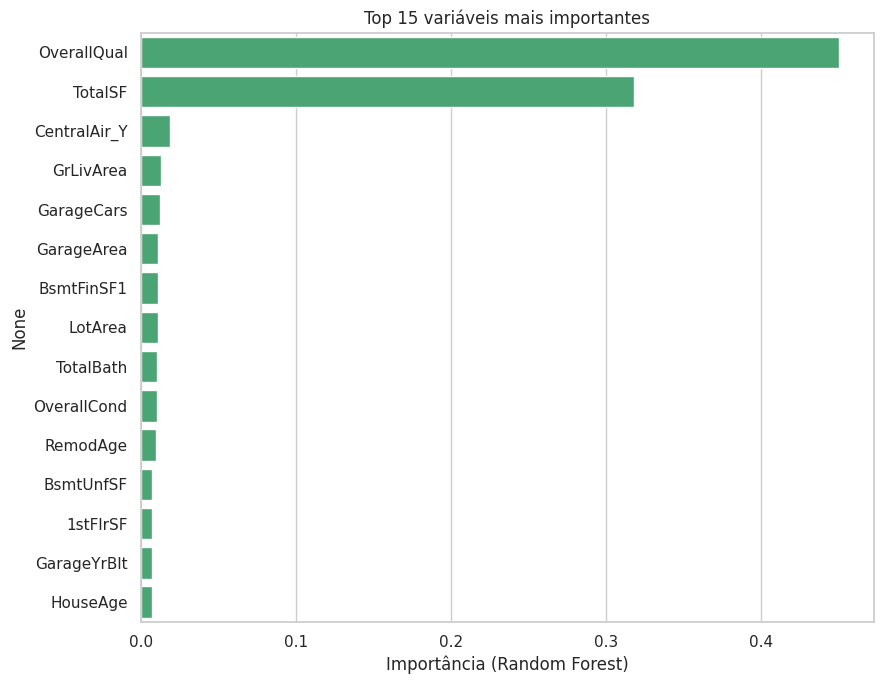

In [38]:
rf_final = tree_models["Random Forest"].fit(X_train_full, y_train)

importances = pd.Series(rf_final.feature_importances_, index=X_train_full.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 7))
sns.barplot(x=top_features.values, y=top_features.index, color="mediumseagreen")
plt.xlabel("Importância (Random Forest)")
plt.title("Top 15 variáveis mais importantes")
plt.tight_layout()
plt.show()

# 7. Comparação dos modelos

Consolidamos o RMSLE médio (validação cruzada) de todos os modelos
treinados até aqui em um único gráfico para facilitar a comparação.

                   RMSLE médio  Desvio padrão
Ridge                 0.114999       0.007963
Lasso                 0.115261       0.007381
ElasticNet            0.115489       0.007569
Gradient Boosting     0.125894       0.010441
Linear Regression     0.130978       0.009562
Random Forest         0.138117       0.007804


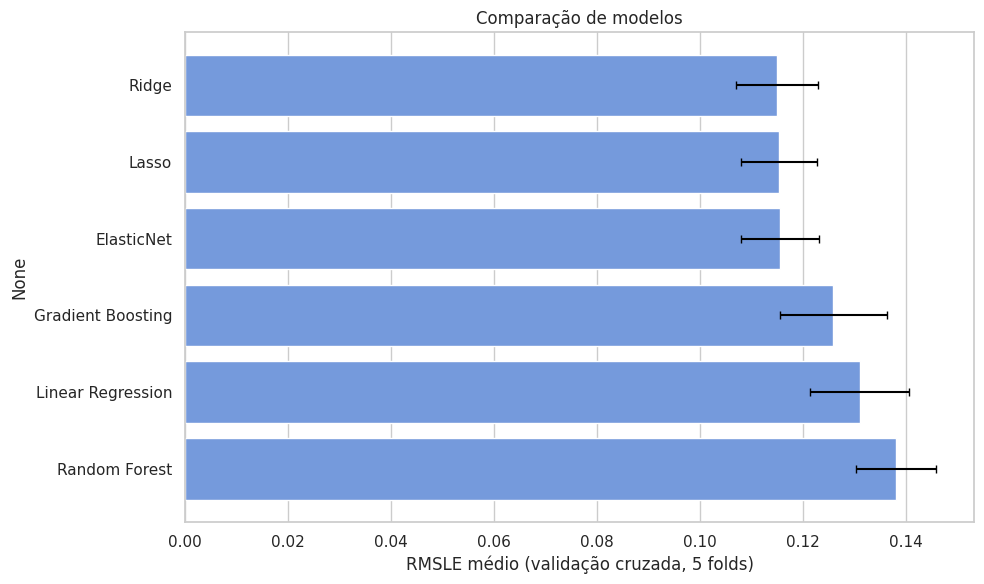


Melhor modelo até o momento: Ridge (RMSLE = 0.1150)


In [41]:
summary = pd.DataFrame({
    name: {"RMSLE médio": scores.mean(), "Desvio padrão": scores.std()}
    for name, scores in results.items()
}).T.sort_values("RMSLE médio")

print(summary)

plt.figure(figsize=(10, 6))
order = summary.index
means = summary["RMSLE médio"]
stds = summary["Desvio padrão"]
sns.barplot(x=means.values, y=order, color="cornflowerblue")
plt.errorbar(means.values, range(len(order)), xerr=stds.values, fmt="none", ecolor="black", capsize=3)
plt.xlabel("RMSLE médio (validação cruzada, 5 folds)")
plt.title("Comparação de modelos")
plt.tight_layout()
plt.show()

best_model_name = summary.index[0]
print(f"\nMelhor modelo até o momento: {best_model_name} "
      f"(RMSLE = {summary.loc[best_model_name, 'RMSLE médio']:.4f})")

# 8. Otimização dos hiperparâmetros

Selecionamos o modelo com melhor desempenho na comparação anterior e
refinamos seus hiperparâmetros com `GridSearchCV`. O código abaixo está
preparado tanto para o caso de o melhor modelo ser o **Gradient Boosting**
quanto o **Random Forest** — ajuste a grade conforme o resultado obtido na
Seção 7 no seu ambiente.

In [42]:
if best_model_name == "Gradient Boosting":
    param_grid = {
        "n_estimators": [300, 500, 800],
        "learning_rate": [0.03, 0.05, 0.1],
        "max_depth": [2, 3, 4],
        "subsample": [0.8, 1.0],
    }
    base_estimator = GradientBoostingRegressor(random_state=SEED)
    X_tune = X_train_full.values

elif best_model_name == "Random Forest":
    param_grid = {
        "n_estimators": [300, 500, 800],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5],
        "max_features": ["sqrt", 1.0],
    }
    base_estimator = RandomForestRegressor(random_state=SEED, n_jobs=-1)
    X_tune = X_train_full.values

else:
    # Ridge / Lasso / ElasticNet / Linear Regression
    param_grid = {"alpha": [0.01, 0.1, 0.3, 1, 3, 5, 10, 15, 20, 30, 50]}
    from sklearn.linear_model import Ridge
    base_estimator = Ridge()
    X_tune = X_train_scaled

grid_search = GridSearchCV(
    base_estimator, param_grid, scoring="neg_mean_squared_error",
    cv=kf, n_jobs=-1, verbose=1
)
grid_search.fit(X_tune, y_train)

best_model = grid_search.best_estimator_
best_rmsle = np.sqrt(-grid_search.best_score_)

print(f"Melhores hiperparâmetros: {grid_search.best_params_}")
print(f"RMSLE (CV) do modelo otimizado: {best_rmsle:.4f}")

Fitting 5 folds for each of 11 candidates, totalling 55 fits
Melhores hiperparâmetros: {'alpha': 15}
RMSLE (CV) do modelo otimizado: 0.1152


# 9. Ensemble dos melhores modelos

In [43]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train, test_size=0.2, random_state=SEED
)
X_tr_scaled = scaler.transform(X_tr)
X_val_scaled = scaler.transform(X_val)

# Reajustamos um modelo linear regularizado e um modelo de árvore no split de treino
ridge_hold = RidgeCV(alphas=alphas_ridge, cv=kf).fit(X_tr_scaled, y_tr)
gb_hold = GradientBoostingRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=3, random_state=SEED
).fit(X_tr, y_tr)

pred_ridge = ridge_hold.predict(X_val_scaled)
pred_gb = gb_hold.predict(X_val)

rmsle_ridge = np.sqrt(mean_squared_error(y_val, pred_ridge))
rmsle_gb = np.sqrt(mean_squared_error(y_val, pred_gb))

# Testamos alguns pesos para a combinação (ensemble)
best_w, best_rmsle_ens = None, np.inf
for w in np.arange(0.0, 1.05, 0.05):
    pred_ens = w * pred_ridge + (1 - w) * pred_gb
    rmsle_ens = np.sqrt(mean_squared_error(y_val, pred_ens))
    if rmsle_ens < best_rmsle_ens:
        best_rmsle_ens, best_w = rmsle_ens, w

print(f"RMSLE (hold-out) Ridge            : {rmsle_ridge:.4f}")
print(f"RMSLE (hold-out) Gradient Boosting: {rmsle_gb:.4f}")
print(f"RMSLE (hold-out) Ensemble (peso Ridge={best_w:.2f}): {best_rmsle_ens:.4f}")

RMSLE (hold-out) Ridge            : 0.1221
RMSLE (hold-out) Gradient Boosting: 0.1267
RMSLE (hold-out) Ensemble (peso Ridge=0.60): 0.1190


# 10. Treinamento final e geração da submissão

Com a estratégia validada, refazemos o treinamento em **100% do conjunto de
treino** (sem hold-out) e geramos as previsões finais para `X_test`. Se o
ensemble (Seção 9) tiver superado os modelos individuais no hold-out,
usamos a combinação ponderada com o peso `best_w` encontrado; caso
contrário, usamos apenas o `best_model` otimizado na Seção 8.

In [44]:
use_ensemble = best_rmsle_ens < min(rmsle_ridge, rmsle_gb)
print(f"Usar ensemble na submissão final? {use_ensemble}")

# Reajuste dos modelos em 100% dos dados de treino
ridge_full = RidgeCV(alphas=alphas_ridge, cv=kf).fit(X_train_scaled, y_train)
gb_full = GradientBoostingRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=3, random_state=SEED
).fit(X_train_full, y_train)

if use_ensemble:
    pred_log = best_w * ridge_full.predict(X_test_scaled) + (1 - best_w) * gb_full.predict(X_test)
else:
    # Usa o melhor modelo individual identificado/otimizado nas seções 7-8
    if best_model_name in ("Ridge", "Lasso", "ElasticNet", "Linear Regression"):
        pred_log = best_model.predict(X_test_scaled)
    else:
        pred_log = best_model.predict(X_test.values)

# Transformação inversa: log1p -> escala original de preço
final_predictions = np.expm1(pred_log)

submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": final_predictions
})

submission.to_csv("submission.csv", index=False)
print("Arquivo 'submission.csv' gerado com sucesso!")
submission.head()

Usar ensemble na submissão final? True
Arquivo 'submission.csv' gerado com sucesso!


,Id,SalePrice
0,1461,120532.138622
1,1462,155574.937404
2,1463,185414.194899
3,1464,195235.189888
4,1465,196870.338743


In [45]:
submission

,Id,SalePrice
0,1461,120532.138622
1,1462,155574.937404
2,1463,185414.194899
3,1464,195235.189888
4,1465,196870.338743
...,...,...
1454,2915,83788.038214
1455,2916,78730.443457
1456,2917,173889.412158
1457,2918,121491.437314


In [ ]:
# No Google Colab, baixe o arquivo de submissão diretamente para o seu computador
if IN_COLAB:
    from google.colab import files
    files.download("submission.csv")

# 11. Considerações Finais

Ao longo do desenvolvimento deste projeto, resolvemos a competição **House Prices - Advanced Regression
Techniques** do Kaggle seguindo um pipeline completo de Machine Learning:

1. **EDA**: identificamos a assimetria de `SalePrice`, o padrão de valores
   ausentes (majoritariamente "ausência de característica") e as variáveis
   mais correlacionadas com o preço, além de dois outliers relevantes;
2. **Pré-processamento**: tratamos valores ausentes de forma específica ao
   significado de cada coluna, criamos atributos derivados (`TotalSF`,
   `HouseAge`, `TotalBath`, entre outros), codificamos variáveis ordinais
   e nominais, e corrigimos a assimetria de variáveis numéricas;
3. **Modelagem**: comparamos modelos lineares regularizados (Ridge, Lasso,
   ElasticNet) com modelos de ensemble baseados em árvores (Random Forest,
   Gradient Boosting), usando **validação cruzada K-Fold** e a métrica
   **RMSLE**, oficial da competição;
4. **Otimização**: refinamos os hiperparâmetros do melhor modelo via
   `GridSearchCV`;
5. **Ensemble**: avaliamos se a combinação de um modelo linear com um
   modelo de árvore melhora a performance em relação aos modelos
   individuais;
6. **Submissão**: geramos o arquivo `submission.csv` no formato exigido
   pelo Kaggle.

### Possíveis melhorias futuras

- Testar modelos de boosting mais avançados, como **XGBoost**, **LightGBM**
  ou **CatBoost** (não incluídos aqui por dependerem de bibliotecas
  externas ao scikit-learn);
- Empilhamento (**stacking**) de modelos com um meta-modelo, em vez de
  apenas uma média ponderada;
- Seleção de atributos mais refinada (ex.: eliminação recursiva de
  atributos - RFE);
- Engenharia de atributos adicional, como interações entre variáveis de
  qualidade e área;
- Análise mais aprofundada de outliers multivariados (não apenas em
  `GrLivArea`).